<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Decision_Tree/DecisionTreeClassifier_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree from Scratch

#  Imported the libraries

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## About the Dataset

We are using the **Banknote Authentication Dataset**, which contains measurements extracted from images of genuine and forged banknotes.

It has **4 numerical features** — variance, skewness, curtosis, and entropy — and a binary target indicating whether a banknote is **genuine or forged**.

This dataset is a good choice for our Decision Tree because it is a **binary classification problem with numerical features**, allowing us to clearly see how the tree learns feature-based threshold splits.

In [44]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

df = pd.read_csv(url, header=None, names=columns)

df.head()



,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


# Visualized the data

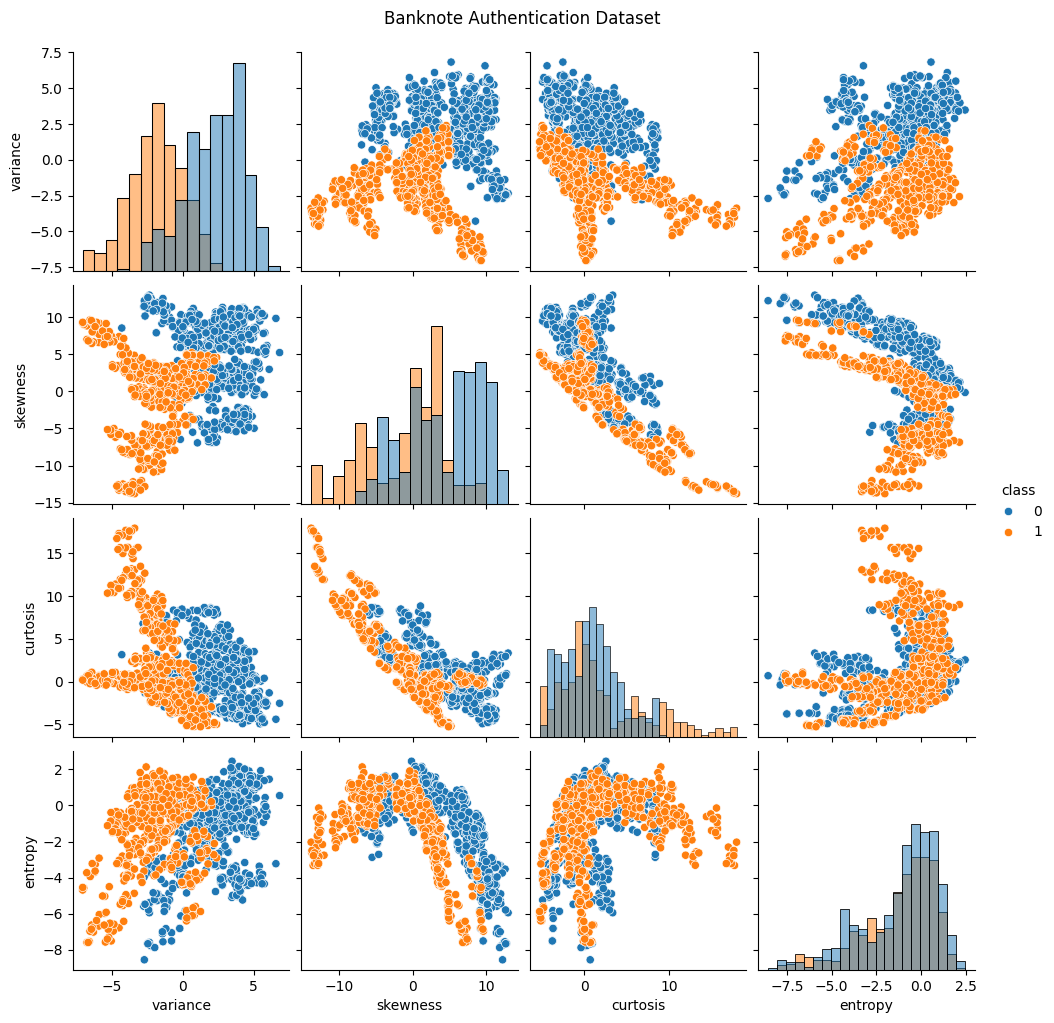

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(
    df,
    hue="class",
    diag_kind="hist"
)

plt.suptitle(
    "Banknote Authentication Dataset",
    y=1.02
)

plt.show()

# Inspecting the data

In [46]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [47]:
df["class"].value_counts()

,count
class,
0,762
1,610


In [48]:
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [49]:
X = df.drop("class", axis=1).values
Y = df["class"].values

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1372, 4)
Y shape: (1372,)


# Train Test split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [51]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1097, 4)
X_test: (275, 4)
y_train: (1097,)
y_test: (275,)


In [52]:
class DecisionTree:

    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None



    # TRAIN

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)
        return self



    # BUILD TREE RECURSIVELY


    def _build_tree(self, X, y, depth=0):

        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Stopping conditions
        if (
            depth >= self.max_depth
            or n_classes == 1
            or n_samples < self.min_samples_split
        ):
            return self._leaf_value(y)

        # Find the best split
        best_feature, best_threshold, best_gain = self._best_split(
            X, y
        )

        # No useful split
        if best_gain <= 0:
            return self._leaf_value(y)

        # Create masks for the split
        left_indices = X[:, best_feature] <= best_threshold
        right_indices = X[:, best_feature] > best_threshold

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        # Recursively build left and right branches
        left_subtree = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_subtree = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        # Store the decision
        return {
            "feature": best_feature,
            "threshold": best_threshold,
            "left": left_subtree,
            "right": right_subtree
        }


    # FIND BEST SPLIT


    def _best_split(self, X, y):

        best_gain = -1
        best_feature = None
        best_threshold = None

        # Try every feature
        for feature in range(X.shape[1]):

            # Possible thresholds
            thresholds = np.unique(X[:, feature])

            # Try every threshold
            for threshold in thresholds:

                left_indices = X[:, feature] <= threshold
                right_indices = X[:, feature] > threshold

                # Skip invalid splits
                if (
                    np.sum(left_indices) == 0
                    or np.sum(right_indices) == 0
                ):
                    continue

                y_left = y[left_indices]
                y_right = y[right_indices]

                # Calculate information gain
                gain = self._information_gain(
                    y,
                    y_left,
                    y_right
                )

                # Keep the best split
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain


    # INFORMATION GAIN

    def _information_gain(self, y, y_left, y_right):

        # Gini impurity before split
        parent_gini = self._gini(y)

        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)

        # Weighted Gini impurity after split
        weighted_gini = (
            (n_left / n) * self._gini(y_left)
            +
            (n_right / n) * self._gini(y_right)
        )

        # Reduction in impurity
        gain = parent_gini - weighted_gini

        return gain



    # GINI IMPURITY


    def _gini(self, y):

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = counts / len(y)

        return 1 - np.sum(probabilities ** 2)



    # LEAF VALUE


    def _leaf_value(self, y):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[np.argmax(counts)]



    # PREDICTION


    def predict(self, X):

        return np.array([
            self._traverse_tree(x, self.tree)
            for x in X
        ])



    # TRAVERSE TREE


    def _traverse_tree(self, x, node):

        # If node is a leaf
        if not isinstance(node, dict):
            return node

        # Follow left or right branch
        if x[node["feature"]] <= node["threshold"]:
            return self._traverse_tree(
                x,
                node["left"]
            )

        return self._traverse_tree(
            x,
            node["right"]
        )



In [53]:
# CREATE AND TRAIN OUR TREE


tree = DecisionTree(
    max_depth=5,
    min_samples_split=2
)

tree.fit(X_train, y_train)

print("\nDecision Tree trained successfully!")





y_pred = tree.predict(X_test)



# EVALUATE


accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)



Decision Tree trained successfully!

Accuracy: 0.9818181818181818

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       153
           1       0.98      0.98      0.98       122

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



In [54]:
import matplotlib.pyplot as plt


def plot_tree(tree, feature_names, node_text=None):

    fig, ax = plt.subplots(figsize=(18, 10))

    def draw_node(node, x, y, dx, depth=0):

        # Leaf node
        if not isinstance(node, dict):

            ax.text(
                x,
                y,
                f"Class: {int(node)}",
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.5",
                    facecolor="lightgreen",
                    edgecolor="black"
                )
            )

            return

        feature = feature_names[node["feature"]]
        threshold = node["threshold"]

        # Current decision
        ax.text(
            x,
            y,
            f"{feature}\n≤ {threshold:.3f}",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor="lightblue",
                edgecolor="black"
            )
        )

        # Child positions
        left_x = x - dx
        right_x = x + dx
        child_y = y - 1

        # Draw branches
        ax.plot(
            [x, left_x],
            [y - 0.05, child_y + 0.05],
            "k-"
        )

        ax.plot(
            [x, right_x],
            [y - 0.05, child_y + 0.05],
            "k-"
        )

        # Branch labels
        ax.text(
            (x + left_x) / 2,
            (y + child_y) / 2,
            "True",
            ha="center"
        )

        ax.text(
            (x + right_x) / 2,
            (y + child_y) / 2,
            "False",
            ha="center"
        )

        draw_node(
            node["left"],
            left_x,
            child_y,
            dx / 2,
            depth + 1
        )

        draw_node(
            node["right"],
            right_x,
            child_y,
            dx / 2,
            depth + 1
        )

    draw_node(
        tree,
        0,
        0,
        8
    )

    ax.axis("off")
    plt.title(
        "Decision Tree From Scratch",
        fontsize=16
    )

    plt.show()

# Final Tree Visualized

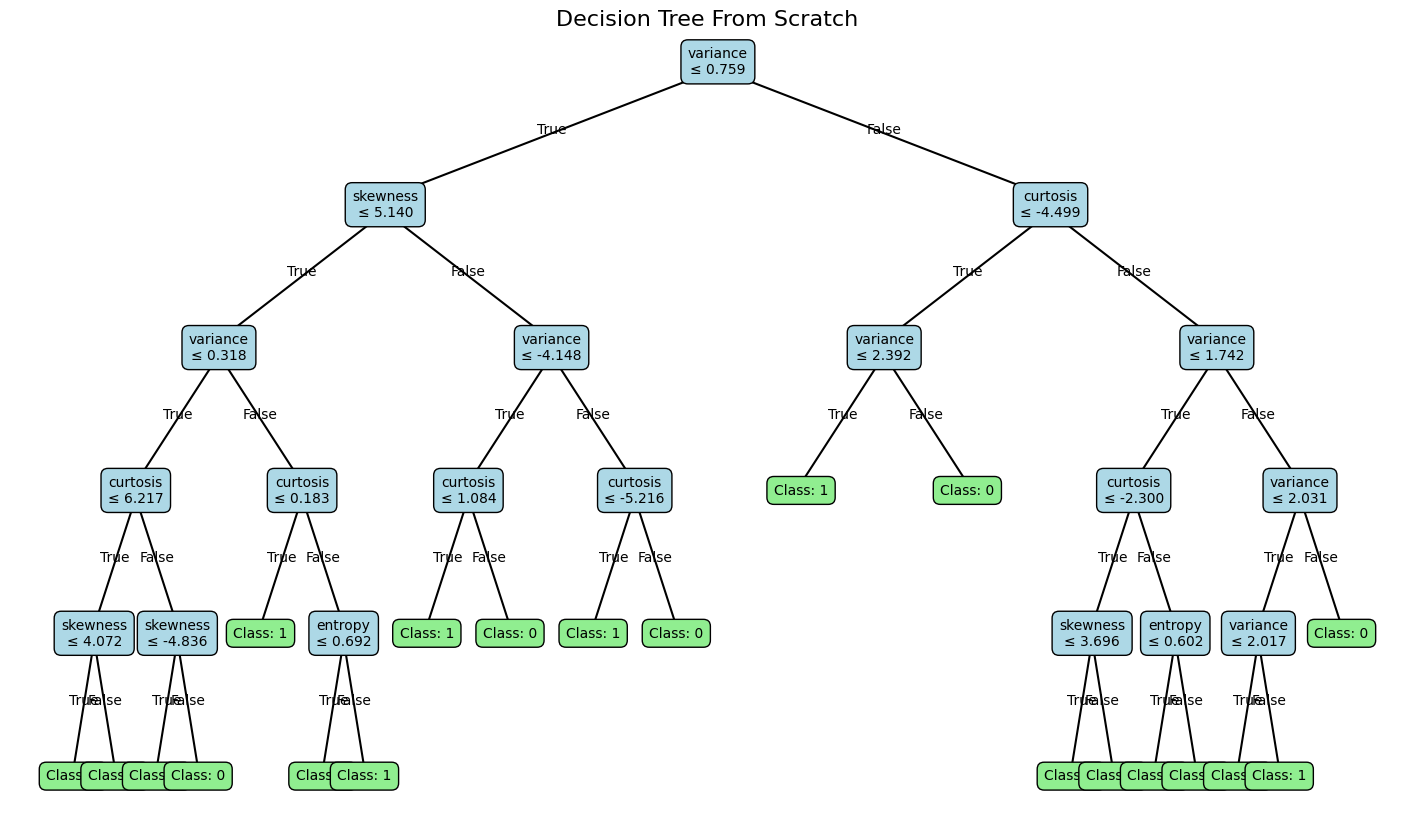

In [55]:
feature_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy"
]

plot_tree(
    tree.tree,
    feature_names
)

## Conclusion

The Decision Tree achieved **98.18% accuracy** on the test set, with precision, recall, and F1-score around **0.98 for both classes**.

This shows that the tree successfully learned useful feature-based decision boundaries for distinguishing genuine and forged banknotes, giving strong and consistent classification performance on unseen data.